In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [32]:
df = pd.read_csv(r"C:\MyCode\AI-ML\EDA\Algerian_forest_fires_dataset_UPDATE_cleaned.csv")


In [33]:
df.head()

,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,1.0
1,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,1.0
2,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,1.0
3,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,1.0
4,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,1.0


In [34]:
df.columns

Index(['month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC',
       'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [35]:
df.drop(['month','year'],axis=1,inplace=True)

In [36]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,1.0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,1.0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,1.0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,1.0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,1.0


In [37]:
df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [38]:
##Encoding
df['Classes'] = df['Classes'].astype(str).apply(lambda x: 0 if 'not fire' in x else 1)


In [39]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [40]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,1.0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,1.0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,1.0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,1.0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,1.0


In [41]:
df.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1.0
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0,1.0
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1.0
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1.0
242,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0,1.0


In [42]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [43]:
## Independent and dependent features
X = df.drop('FWI',axis=1)
Y=df['FWI']


In [44]:
Y


0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
238    6.5
239    0.0
240    0.2
241    0.7
242    0.5
Name: FWI, Length: 243, dtype: float64

In [45]:
X

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,1.0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,1.0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,1.0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,1.0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,1,1.0
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0,1.0
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0,1.0
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0,1.0


In [ ]:
##Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.25,random_state=42)

In [47]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((194, 11), (49, 11), (194,), (49,))

In [48]:
##Feature selection based on correlation
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.678630,-0.340428,-0.374077,0.695205,0.516482,0.391863,0.619642,0.483821,0.528497,NaN
RH,-0.678630,1.000000,0.268352,0.244651,-0.656326,-0.404728,-0.227774,-0.694710,-0.349811,-0.440776,NaN
Ws,-0.340428,0.268352,1.000000,0.148954,-0.183780,-0.014685,0.092298,-0.017768,0.027946,-0.083786,NaN
Rain,-0.374077,0.244651,0.148954,1.000000,-0.578420,-0.316594,-0.297355,-0.354426,-0.319805,-0.399671,NaN
FFMC,0.695205,-0.656326,-0.183780,-0.578420,1.000000,0.608297,0.500585,0.728146,0.591433,0.749313,NaN
DMC,0.516482,-0.404728,-0.014685,-0.316594,0.608297,1.000000,0.885146,0.673546,0.982560,0.605673,NaN
DC,0.391863,-0.227774,0.092298,-0.297355,0.500585,0.885146,1.000000,0.494613,0.946112,0.522334,NaN
ISI,0.619642,-0.694710,-0.017768,-0.354426,0.728146,0.673546,0.494613,1.000000,0.634079,0.735517,NaN
BUI,0.483821,-0.349811,0.027946,-0.319805,0.591433,0.982560,0.946112,0.634079,1.000000,0.604339,NaN
Classes,0.528497,-0.440776,-0.083786,-0.399671,0.749313,0.605673,0.522334,0.735517,0.604339,1.000000,NaN


In [50]:
X_test.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.488263,-0.015334,-0.202303,0.587344,0.321371,0.285322,0.515414,0.325748,0.491610,NaN
RH,-0.488263,1.000000,0.106539,0.185515,-0.578342,-0.438919,-0.227182,-0.642666,-0.383894,-0.395240,NaN
Ws,-0.015334,0.106539,1.000000,0.276543,-0.066880,0.053264,0.003550,0.139642,0.037326,0.022340,NaN
Rain,-0.202303,0.185515,0.276543,1.000000,-0.505882,-0.225918,-0.325800,-0.364554,-0.262812,-0.366045,NaN
FFMC,0.587344,-0.578342,-0.066880,-0.505882,1.000000,0.589171,0.550875,0.808289,0.603089,0.870898,NaN
DMC,0.321371,-0.438919,0.053264,-0.225918,0.589171,1.000000,0.831425,0.717437,0.981096,0.515450,NaN
DC,0.285322,-0.227182,0.003550,-0.325800,0.550875,0.831425,1.000000,0.583197,0.921170,0.478436,NaN
ISI,0.515414,-0.642666,0.139642,-0.364554,0.808289,0.717437,0.583197,1.000000,0.697013,0.751792,NaN
BUI,0.325748,-0.383894,0.037326,-0.262812,0.603089,0.981096,0.921170,0.697013,1.000000,0.525414,NaN
Classes,0.491610,-0.395240,0.022340,-0.366045,0.870898,0.515450,0.478436,0.751792,0.525414,1.000000,NaN


<Axes: >

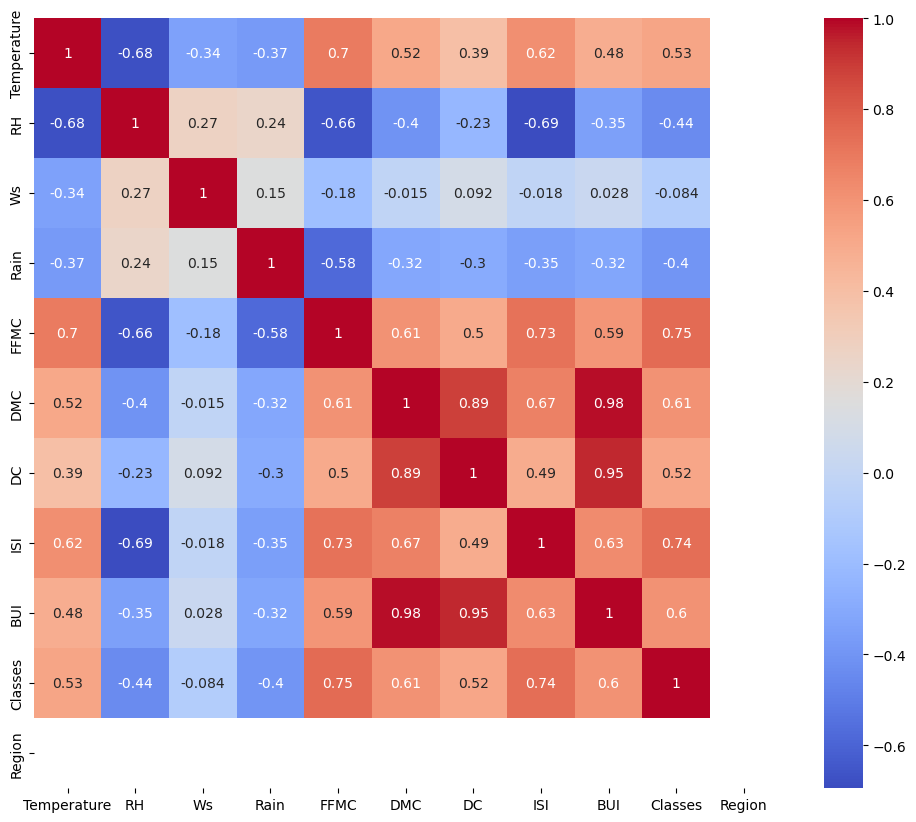

In [52]:
##Check for multicollinearity
plt.figure(figsize=(12,10))
corr=X_train.corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')

In [53]:
def correlation(dataset, threshold):
    col_corr = set()  # Set of all the names of deleted columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:  # we are interested in absolute coeff value
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)
    return col_corr

In [58]:
correlation(X_train, 0.8)
X_train_scaled = X_train.drop(['DC', 'ISI'], axis=1)

Text(0.5, 1.0, 'X_train after scaling')

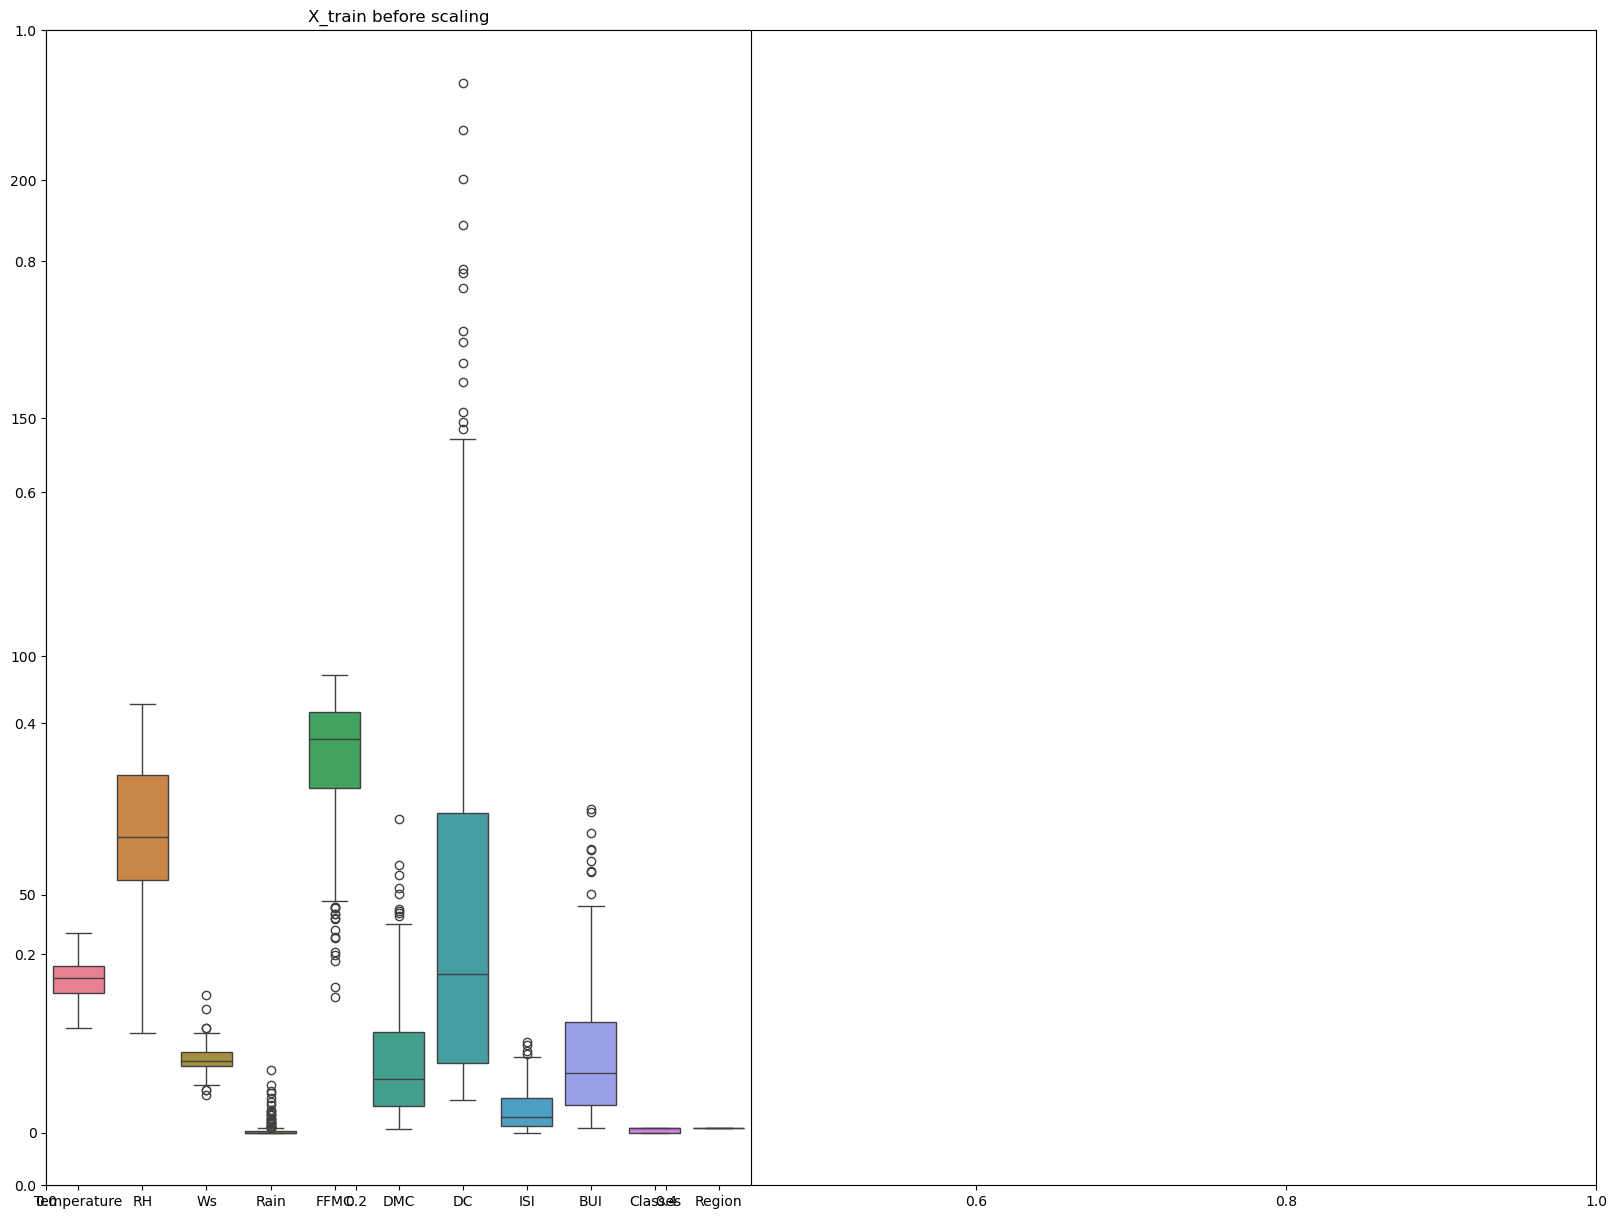

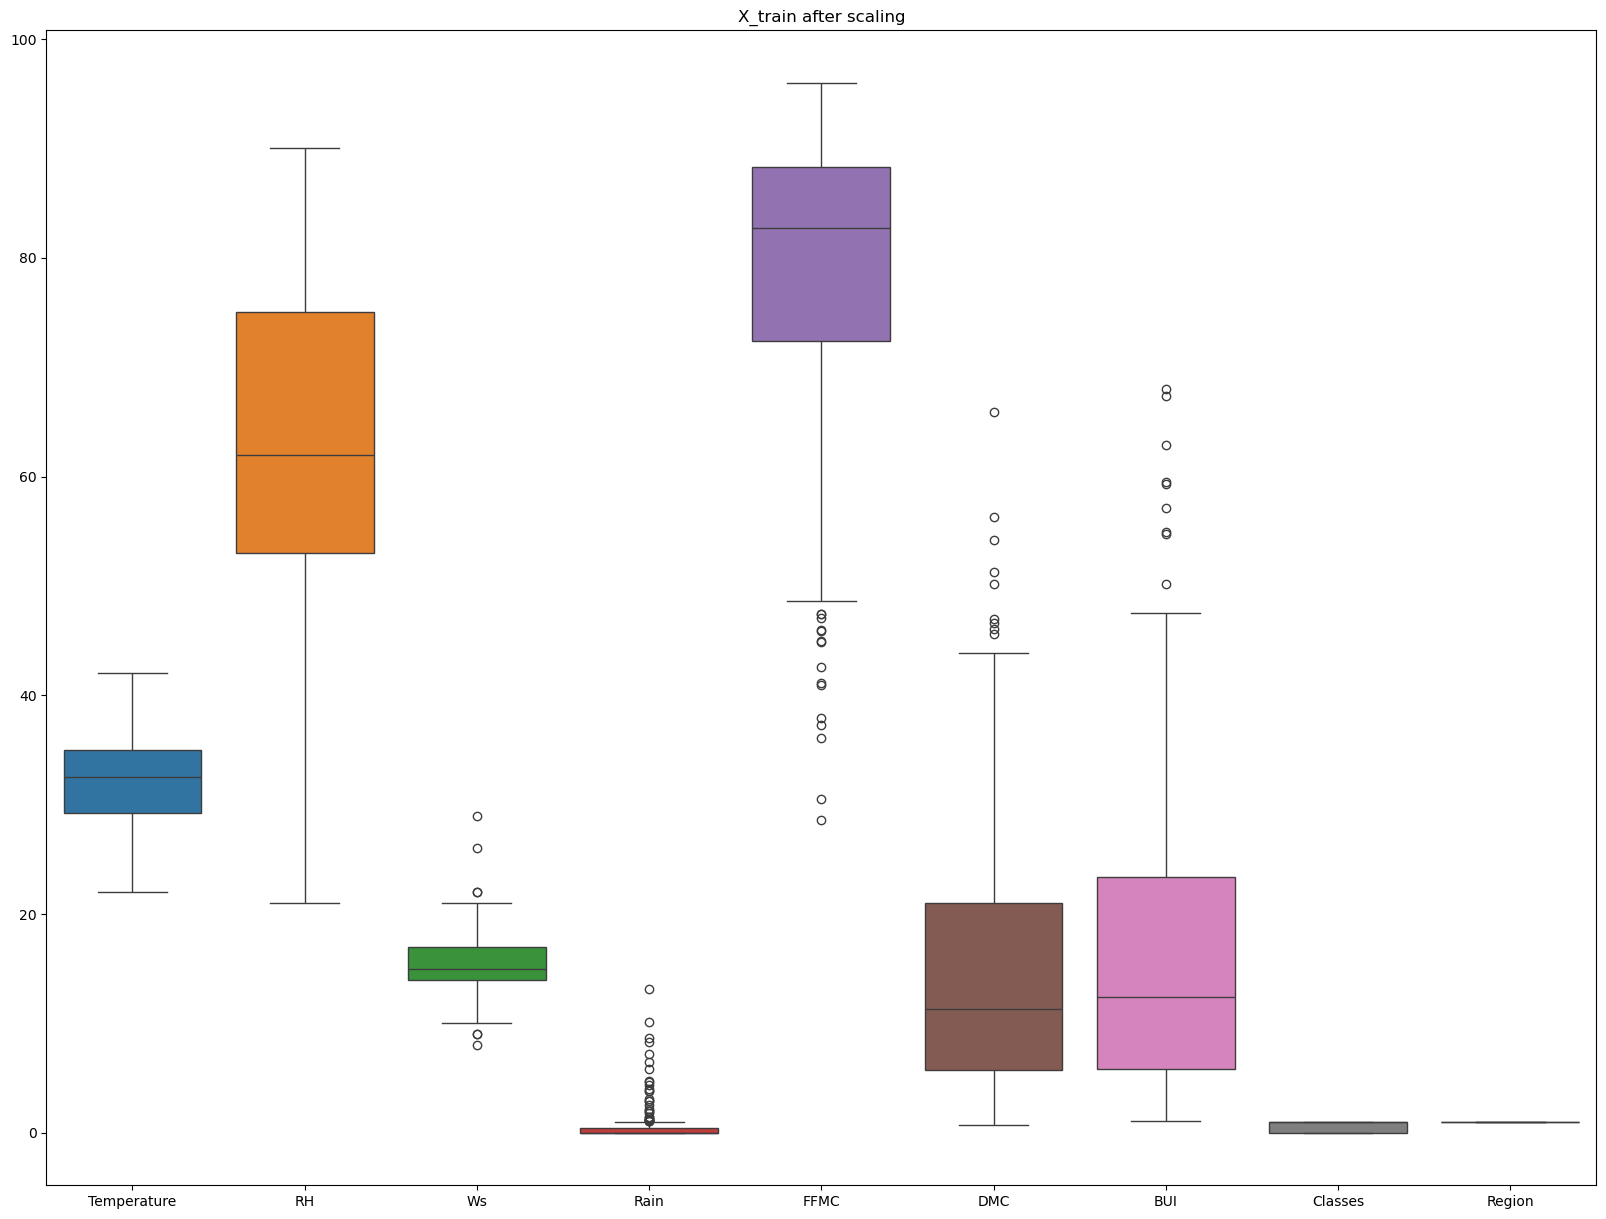

In [60]:
##Box plots to understand the effect to std scaler
plt.subplots(figsize=(20, 15))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title('X_train before scaling')
plt.subplots(figsize=(20, 15))
sns.boxplot(data=X_train_scaled)
plt.title('X_train after scaling')


Linear Regression Model

In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

linreg = LinearRegression()
linreg.fit(X_train, Y_train)

# Use scaled test data for prediction
y_pred = linreg.predict(X_test)

mae = mean_absolute_error(Y_test, y_pred)
score = r2_score(Y_test, y_pred)

print('Mean Absolute Error:', mae)
print('R2 Score:', score)

Mean Absolute Error: 0.5940670785794601
R2 Score: 0.985410026341757
